In [1]:

# basic packages
import pandas as pd
import numpy as np
import datetime as dt
from pytz import timezone
import urllib
import os
import math
from scipy import stats
from scipy.signal import find_peaks, spectrogram

# packages for visualizations
import matplotlib.dates as mdates

from matplotlib import pyplot as plt


In [2]:
ev_load = './cleansed_data_EV/GreenFlux3Minute.csv'

df=pd.read_csv(ev_load)



df

,ChargerID,GroupID,TimeStamp,AdjustedTimeStamp,MaxAmpsUsed,AmpsAllocated,TransactionID
0,UK-GFX-ENA0073,GF0008,2018-01-10 16:00:00.000,2018-01-10 16:00:00.000,0.0,13.0,27273.0
1,UK-GFX-ENA0008,GF0012,2018-03-26 22:53:00.000,2018-03-26 23:53:00.000,16.2,16.0,41206.0
2,UK-GFX-ENA0014,GFAppPilot02,2018-04-25 07:14:00.000,2018-04-25 08:14:00.000,0.0,13.0,45654.0
3,UK-GFX-ENA0119,GF0010,2018-02-05 01:12:00.000,2018-02-05 01:12:00.000,0.0,13.0,31455.0
4,UK-GFX-ENA0142,GF0010,2018-02-06 07:53:00.000,2018-02-06 07:53:00.000,0.0,13.0,32043.0
...,...,...,...,...,...,...,...
16696921,UK-GFX-ENA0179,GF0012,2018-03-08 01:07:00.000,2018-03-08 01:07:00.000,0.0,32.0,37344.0
16696922,UK-GFX-ENA0266,Does not exist,2018-08-22 19:45:00.000,2018-08-22 20:45:00.000,0.0,32.0,NaN
16696923,UK-GFX-ENA0055,Does not exist,2017-07-16 10:39:00.000,2017-07-16 11:39:00.000,31.6,32.0,NaN
16696924,UK-GFX-ENA0231,GF0012,2018-03-11 07:18:00.000,2018-03-11 07:18:00.000,0.0,32.0,38300.0


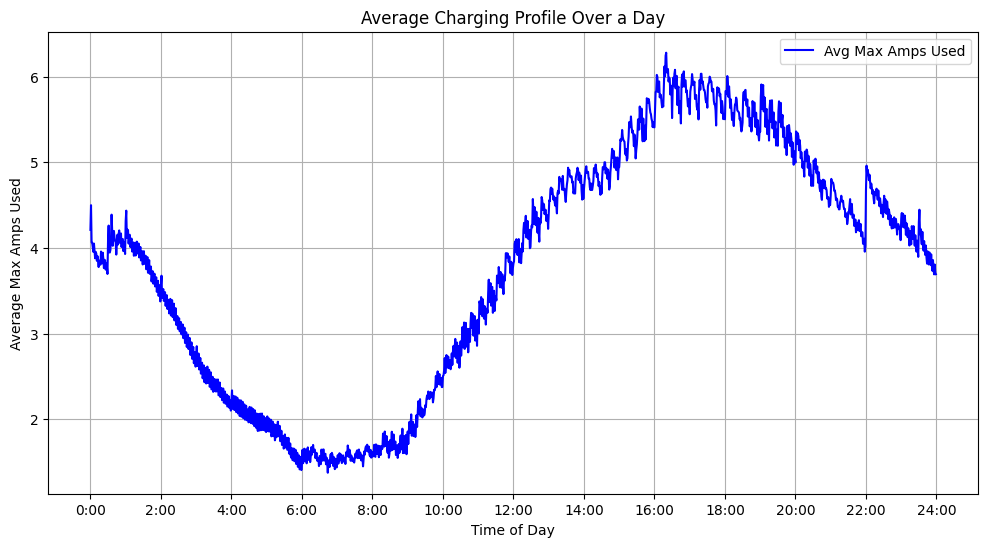

In [3]:


# Convert TimeStamp to datetime
df["TimeStamp"] = pd.to_datetime(df["TimeStamp"])

# Extract only the time of day as minutes since midnight
df["MinutesSinceMidnight"] = df["TimeStamp"].dt.hour * 60 + df["TimeStamp"].dt.minute

# Group by minutes and average MaxAmpsUsed
df_avg_day = df.groupby("MinutesSinceMidnight")["MaxAmpsUsed"].mean().reset_index()

# Plot the average day
plt.figure(figsize=(12, 6))
plt.plot(df_avg_day["MinutesSinceMidnight"], df_avg_day["MaxAmpsUsed"], label="Avg Max Amps Used", color="b")

# Formatting
plt.xlabel("Time of Day")
plt.ylabel("Average Max Amps Used")
plt.title("Average Charging Profile Over a Day")
plt.legend()
plt.xticks(
    ticks=range(0, 1441, 120),  # Every 2 hours
    labels=[f"{h}:00" for h in range(0, 25, 2)]
)
plt.grid(True)

# Show plot
plt.show()

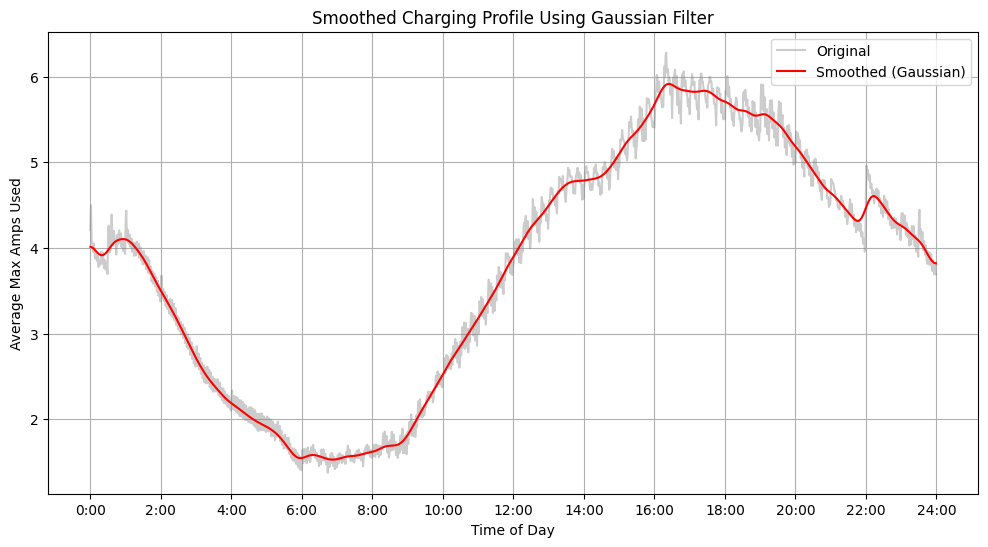

In [4]:
from scipy.ndimage import gaussian_filter1d

# Apply Gaussian filter
df_avg_day["Smoothed"] = gaussian_filter1d(df_avg_day["MaxAmpsUsed"], sigma=10)  # Adjust sigma for smoothness

# Plot
plt.figure(figsize=(12, 6))
plt.plot(df_avg_day["MinutesSinceMidnight"], df_avg_day["MaxAmpsUsed"], alpha=0.4, label="Original", color="gray")
plt.plot(df_avg_day["MinutesSinceMidnight"], df_avg_day["Smoothed"], label="Smoothed (Gaussian)", color="r")

# Formatting
plt.xlabel("Time of Day")
plt.ylabel("Average Max Amps Used")
plt.title("Smoothed Charging Profile Using Gaussian Filter")
plt.legend()
plt.xticks(
    ticks=range(0, 1441, 120),
    labels=[f"{h}:00" for h in range(0, 25, 2)]
)
plt.grid(True)
plt.show()
